# Experiment 04: Study and Simulation of GSM Network Architecture

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 2 digital cellular/GSM entities; William C. Y. Lee GSM architecture sections; course Master Study Notes.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To study the major GSM network entities and create a simple logical simulation of GSM architecture and call setup.

## Objectives

- Identify MS, BTS, BSC, MSC, HLR, VLR, AUC, EIR, and PSTN.
- Understand the relationship between the mobile station, base-station subsystem, and switching subsystem.
- Visualize a simplified GSM architecture.
- Demonstrate a basic mobile-originated call setup sequence.

## Theory

The course describes a digital cellular system using four main elements: **Mobile Station (MS), Base Transceiver Station (BTS), Base Station Controller (BSC), and switching subsystems**.

### Main GSM Entities

- **MS (Mobile Station):** User equipment; in GSM it includes mobile equipment and subscriber identity information stored in the SIM.
- **BTS (Base Transceiver Station):** Provides the radio transmission/reception link to the mobile.
- **BSC (Base Station Controller):** Controls multiple BTSs and performs radio-resource management, handover control, power management, synchronization, and frequency reallocation.
- **MSC (Mobile Switching Center):** Coordinates call setup and switching between mobile subscribers and external networks.
- **HLR (Home Location Register):** Central subscriber database.
- **VLR (Visitor Location Register):** Temporary subscriber/location data for mobiles currently served by an MSC area.
- **AUC (Authentication Center):** Works with the HLR to supply authentication and ciphering parameters.
- **EIR (Equipment Identity Register):** Stores mobile-equipment identity information.
- **PSTN:** External public telephone network.

### Important GSM Interfaces

A simplified chain is

$$
\text{MS}\xleftrightarrow{\text{Um}}\text{BTS}
\xleftrightarrow{\text{Abis}}\text{BSC}
\xleftrightarrow{\text{A}}\text{MSC}
$$

The architecture simulation below represents logical connectivity, not a packet-level GSM protocol stack.

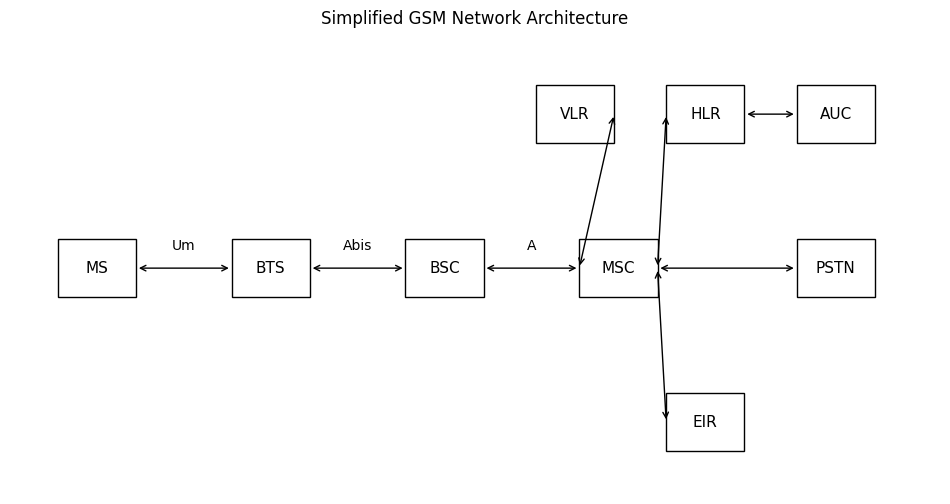

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

nodes = {
    "MS": (0.5, 2.0),
    "BTS": (2.5, 2.0),
    "BSC": (4.5, 2.0),
    "MSC": (6.5, 2.0),
    "PSTN": (9.0, 2.0),
    "HLR": (7.5, 3.5),
    "VLR": (6.0, 3.5),
    "AUC": (9.0, 3.5),
    "EIR": (7.5, 0.5),
}

edges = [
    ("MS", "BTS", "Um"),
    ("BTS", "BSC", "Abis"),
    ("BSC", "MSC", "A"),
    ("MSC", "PSTN", ""),
    ("MSC", "HLR", ""),
    ("MSC", "VLR", ""),
    ("HLR", "AUC", ""),  # the AUC is associated with the HLR
    ("MSC", "EIR", ""),
]

plt.figure(figsize=(12, 6))

for name, (x, y) in nodes.items():
    box = Rectangle((x - 0.45, y - 0.28), 0.9, 0.56, fill=False)
    plt.gca().add_patch(box)
    plt.text(x, y, name, ha="center", va="center", fontsize=11)

for start, end, label in edges:
    x1, y1 = nodes[start]
    x2, y2 = nodes[end]
    plt.annotate(
        "",
        xy=(x2 - 0.45 if x2 > x1 else x2 + 0.45, y2),
        xytext=(x1 + 0.45 if x2 > x1 else x1 - 0.45, y1),
        arrowprops=dict(arrowstyle="<->")  # GSM links are bidirectional
    )
    if label:
        plt.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.18, label, ha="center")

plt.xlim(-0.5, 10.2)
plt.ylim(-0.2, 4.3)
plt.axis("off")
plt.title("Simplified GSM Network Architecture")
plt.show()

**Observation:** The radio path ends at the BTS. The BSC manages radio resources across BTSs, while the MSC connects the radio access side to subscriber databases and external networks.

## Simplified Mobile-Originated Call Setup

A complete GSM call procedure contains many signalling details. For this laboratory, the sequence is deliberately simplified to highlight the roles of the major entities:

1. MS requests access through the BTS.
2. BTS forwards the request toward the BSC.
3. BSC requests call setup from the MSC.
4. MSC checks subscriber/location/security-related information.
5. Radio resources are assigned through BSC/BTS.
6. MSC establishes the connection toward the destination network.

In [2]:
call_setup_steps = [
    ("MS", "BTS", "Random access / service request"),
    ("BTS", "BSC", "Forward access request"),
    ("BSC", "MSC", "Call setup request"),
    ("MSC", "VLR/HLR/AUC", "Subscriber and security checks"),
    ("MSC", "BSC", "Authorize traffic-channel setup"),
    ("BSC", "BTS", "Activate radio traffic channel"),
    ("BTS", "MS", "Assign traffic channel"),
    ("MSC", "PSTN / Destination", "Establish outgoing connection"),
    ("Network", "MS", "Call connected"),
]

for step_number, (source, destination, action) in enumerate(call_setup_steps, start=1):
    print(f"{step_number:02d}. {source:10s} -> {destination:20s}: {action}")

01. MS         -> BTS                 : Random access / service request
02. BTS        -> BSC                 : Forward access request
03. BSC        -> MSC                 : Call setup request
04. MSC        -> VLR/HLR/AUC         : Subscriber and security checks
05. MSC        -> BSC                 : Authorize traffic-channel setup
06. BSC        -> BTS                 : Activate radio traffic channel
07. BTS        -> MS                  : Assign traffic channel
08. MSC        -> PSTN / Destination  : Establish outgoing connection
09. Network    -> MS                  : Call connected


## Result and Discussion

The generated diagram shows the major GSM entities and their logical connections. The call-flow output demonstrates that radio access is handled by the BTS/BSC side while switching and subscriber management are coordinated through the MSC and network databases.

## Conclusion

GSM architecture was studied and represented using a clear Python visualization and a simplified call-setup simulation suitable for an undergraduate laboratory.

## Viva Questions and Short Answers

1. **What is the function of BTS?**  
   It provides the radio transmission and reception link to the mobile station.

2. **What is the main function of BSC?**  
   Radio-resource management for multiple BTSs/cells, including handover and power/frequency management.

3. **What does MSC do?**  
   It coordinates switching and call setup between mobile users and external networks.

4. **What is the difference between HLR and VLR?**  
   HLR is the central subscriber database; VLR stores temporary information for subscribers currently in an MSC area.

5. **What is the role of AUC?**  
   It provides authentication and ciphering parameters for security.